# ASL Recognition - Model Training (Memory Optimized)

**Models:** EfficientNetB0, MobileNetV2, VGG16, Xception | **Epochs:** 10

In [1]:
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, VGG16, Xception
from tensorflow.keras.applications import efficientnet, mobilenet_v2, vgg16, xception
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# Configuration - MEMORY OPTIMIZED
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10  # Reduced from 15
NUM_CLASSES = 29

# Paths
TRAIN_DIR = '../dataset/asl_alphabet_train/asl_alphabet_train'
MODEL_SAVE_DIR = '../models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print(f"Epochs: {EPOCHS}, Batch: {BATCH_SIZE}")
print(f"Train dir: {os.path.exists(TRAIN_DIR)}")

Epochs: 10, Batch: 32
Train dir: True


In [3]:
# Model configs
MODEL_CONFIGS = {
    'efficientnet': {'base': EfficientNetB0, 'preprocess': efficientnet.preprocess_input, 'name': 'EfficientNetB0'},
    'mobilenet': {'base': MobileNetV2, 'preprocess': mobilenet_v2.preprocess_input, 'name': 'MobileNetV2'},
    'vgg16': {'base': VGG16, 'preprocess': vgg16.preprocess_input, 'name': 'VGG16'},
    'xception': {'base': Xception, 'preprocess': xception.preprocess_input, 'name': 'Xception'}
}

In [4]:
def clear_memory():
    """Clear GPU/CPU memory between models."""
    K.clear_session()
    gc.collect()
    print("Memory cleared.")

def create_generators(preprocess_fn):
    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        validation_split=0.2
    )
    train = datagen.flow_from_directory(TRAIN_DIR, target_size=(IMG_SIZE,IMG_SIZE), 
                                        batch_size=BATCH_SIZE, class_mode='categorical', subset='training')
    val = datagen.flow_from_directory(TRAIN_DIR, target_size=(IMG_SIZE,IMG_SIZE), 
                                      batch_size=BATCH_SIZE, class_mode='categorical', subset='validation', shuffle=False)
    return train, val

def create_model(config):
    base = config['base'](weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(base.input, out, name=config['name'])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint(f'{MODEL_SAVE_DIR}/{name}_best.keras', monitor='val_accuracy', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ]

## Train All Models

In [5]:
results = {}
all_histories = {}

for key, config in MODEL_CONFIGS.items():
    print(f"\n{'='*50}")
    print(f"Training: {config['name']}")
    print(f"{'='*50}")
    
    clear_memory()  # Clear memory before each model
    
    train_gen, val_gen = create_generators(config['preprocess'])
    class_labels = list(train_gen.class_indices.keys())
    
    model = create_model(config)
    start = time.time()
    
    history = model.fit(train_gen, epochs=EPOCHS, validation_data=val_gen, 
                        callbacks=get_callbacks(key), verbose=1)
    
    train_time = time.time() - start
    best_acc = max(history.history['val_accuracy'])
    
    results[key] = {'val_acc': best_acc, 'time': train_time, 'params': model.count_params()}
    all_histories[key] = history.history
    
    print(f"\n✓ {config['name']}: {best_acc:.2%} in {train_time/60:.1f} min")
    
    # Save model reference to disk, then delete from memory
    model.save(f'{MODEL_SAVE_DIR}/{key}_final.keras')
    del model, train_gen, val_gen
    clear_memory()

print("\n" + "="*50)
print("ALL TRAINING COMPLETE!")
print("="*50)


Training: EfficientNetB0
Memory cleared.
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


2025-12-22 14:18:00.539387: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-12-22 14:18:00.539420: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-22 14:18:00.539428: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-22 14:18:00.539443: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-22 14:18:00.539454: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/10


2025-12-22 14:18:03.507708: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 351s 159ms/step - accuracy: 0.8647 - loss: 0.4321 - val_accuracy: 0.8879 - val_loss: 0.3237 - learning_rate: 0.0010
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 332s 152ms/step - accuracy: 0.9487 - loss: 0.1566 - val_accuracy: 0.8848 - val_loss: 0.4109 - learning_rate: 0.0010
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 334s 154ms/step - accuracy: 0.9536 - loss: 0.1455 - val_accuracy: 0.8970 - val_loss: 0.4155 - learning_rate: 0.0010
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 333s 153ms/step - accuracy: 0.9704 - loss: 0.0937 - val_accuracy: 0.8976 - val_loss: 0.3984 - learning_rate: 5.0000e-04

✓ EfficientNetB0: 89.76% in 22.5 min
Memory cleared.

Training: MobileNetV2
Memory cleared.
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 342s 156ms/step - accuracy: 0.7222 - loss: 1.2626 - val_accuracy: 0.8194 - val_loss: 0.6852 - learning_rate: 0.0010
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━

## Results Comparison

In [6]:
# Results table
df = pd.DataFrame({
    'Model': [MODEL_CONFIGS[k]['name'] for k in results],
    'Val Accuracy': [f"{results[k]['val_acc']:.2%}" for k in results],
    'Time (min)': [f"{results[k]['time']/60:.1f}" for k in results],
    'Parameters': [f"{results[k]['params']:,}" for k in results]
})
print(df.to_string(index=False))

# Best model
best_key = max(results, key=lambda k: results[k]['val_acc'])
print(f"\n🏆 BEST: {MODEL_CONFIGS[best_key]['name']} = {results[best_key]['val_acc']:.2%}")

         Model Val Accuracy Time (min) Parameters
EfficientNetB0       89.76%       22.5  4,384,960
   MobileNetV2       85.90%       27.9  2,593,373
         VGG16       82.37%       33.0 14,853,469
      Xception       81.91%       64.3 21,393,477

🏆 BEST: EfficientNetB0 = 89.76%


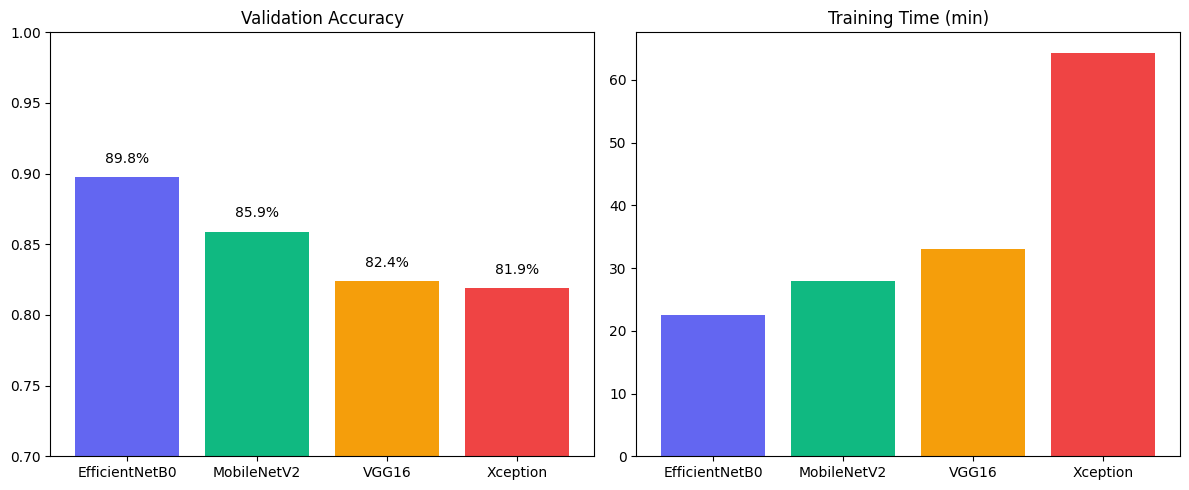

In [7]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#6366f1', '#10b981', '#f59e0b', '#ef4444']

names = [MODEL_CONFIGS[k]['name'] for k in results]
accs = [results[k]['val_acc'] for k in results]
times = [results[k]['time']/60 for k in results]

axes[0].bar(names, accs, color=colors)
axes[0].set_title('Validation Accuracy')
axes[0].set_ylim([0.7, 1.0])
for i, a in enumerate(accs): axes[0].text(i, a+0.01, f'{a:.1%}', ha='center')

axes[1].bar(names, times, color=colors)
axes[1].set_title('Training Time (min)')

plt.tight_layout()
plt.savefig(f'{MODEL_SAVE_DIR}/comparison.png', dpi=150)
plt.show()

## Classification Reports & Confusion Matrices

In [8]:
# Classification reports for all models
print("CLASSIFICATION REPORTS")
print("="*60)

for key, config in MODEL_CONFIGS.items():
    print(f"\n{config['name']}")
    print("-"*40)
    
    clear_memory()
    model = load_model(f'{MODEL_SAVE_DIR}/{key}_final.keras')
    _, val_gen = create_generators(config['preprocess'])
    val_gen.reset()
    
    preds = model.predict(val_gen, verbose=0)
    pred_cls = np.argmax(preds, axis=1)
    true_cls = val_gen.classes
    
    print(classification_report(true_cls, pred_cls, target_names=class_labels))
    del model

CLASSIFICATION REPORTS

EfficientNetB0
----------------------------------------
Memory cleared.
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
              precision    recall  f1-score   support

           A       0.89      1.00      0.94       600
           B       0.97      1.00      0.98       600
           C       0.97      0.97      0.97       600
           D       1.00      0.88      0.93       600
           E       0.92      0.94      0.93       600
           F       1.00      0.99      1.00       600
           G       0.96      0.94      0.95       600
           H       0.89      0.99      0.94       600
           I       0.89      0.81      0.85       600
           J       0.92      0.82      0.87       600
           K       0.97      0.96      0.96       600
           L       0.99      0.98      0.99       600
           M       0.71      0.96      0.81       600
           N       0.88      0.60      0.71       600
     

Memory cleared.
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Memory cleared.
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Memory cleared.
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Memory cleared.
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


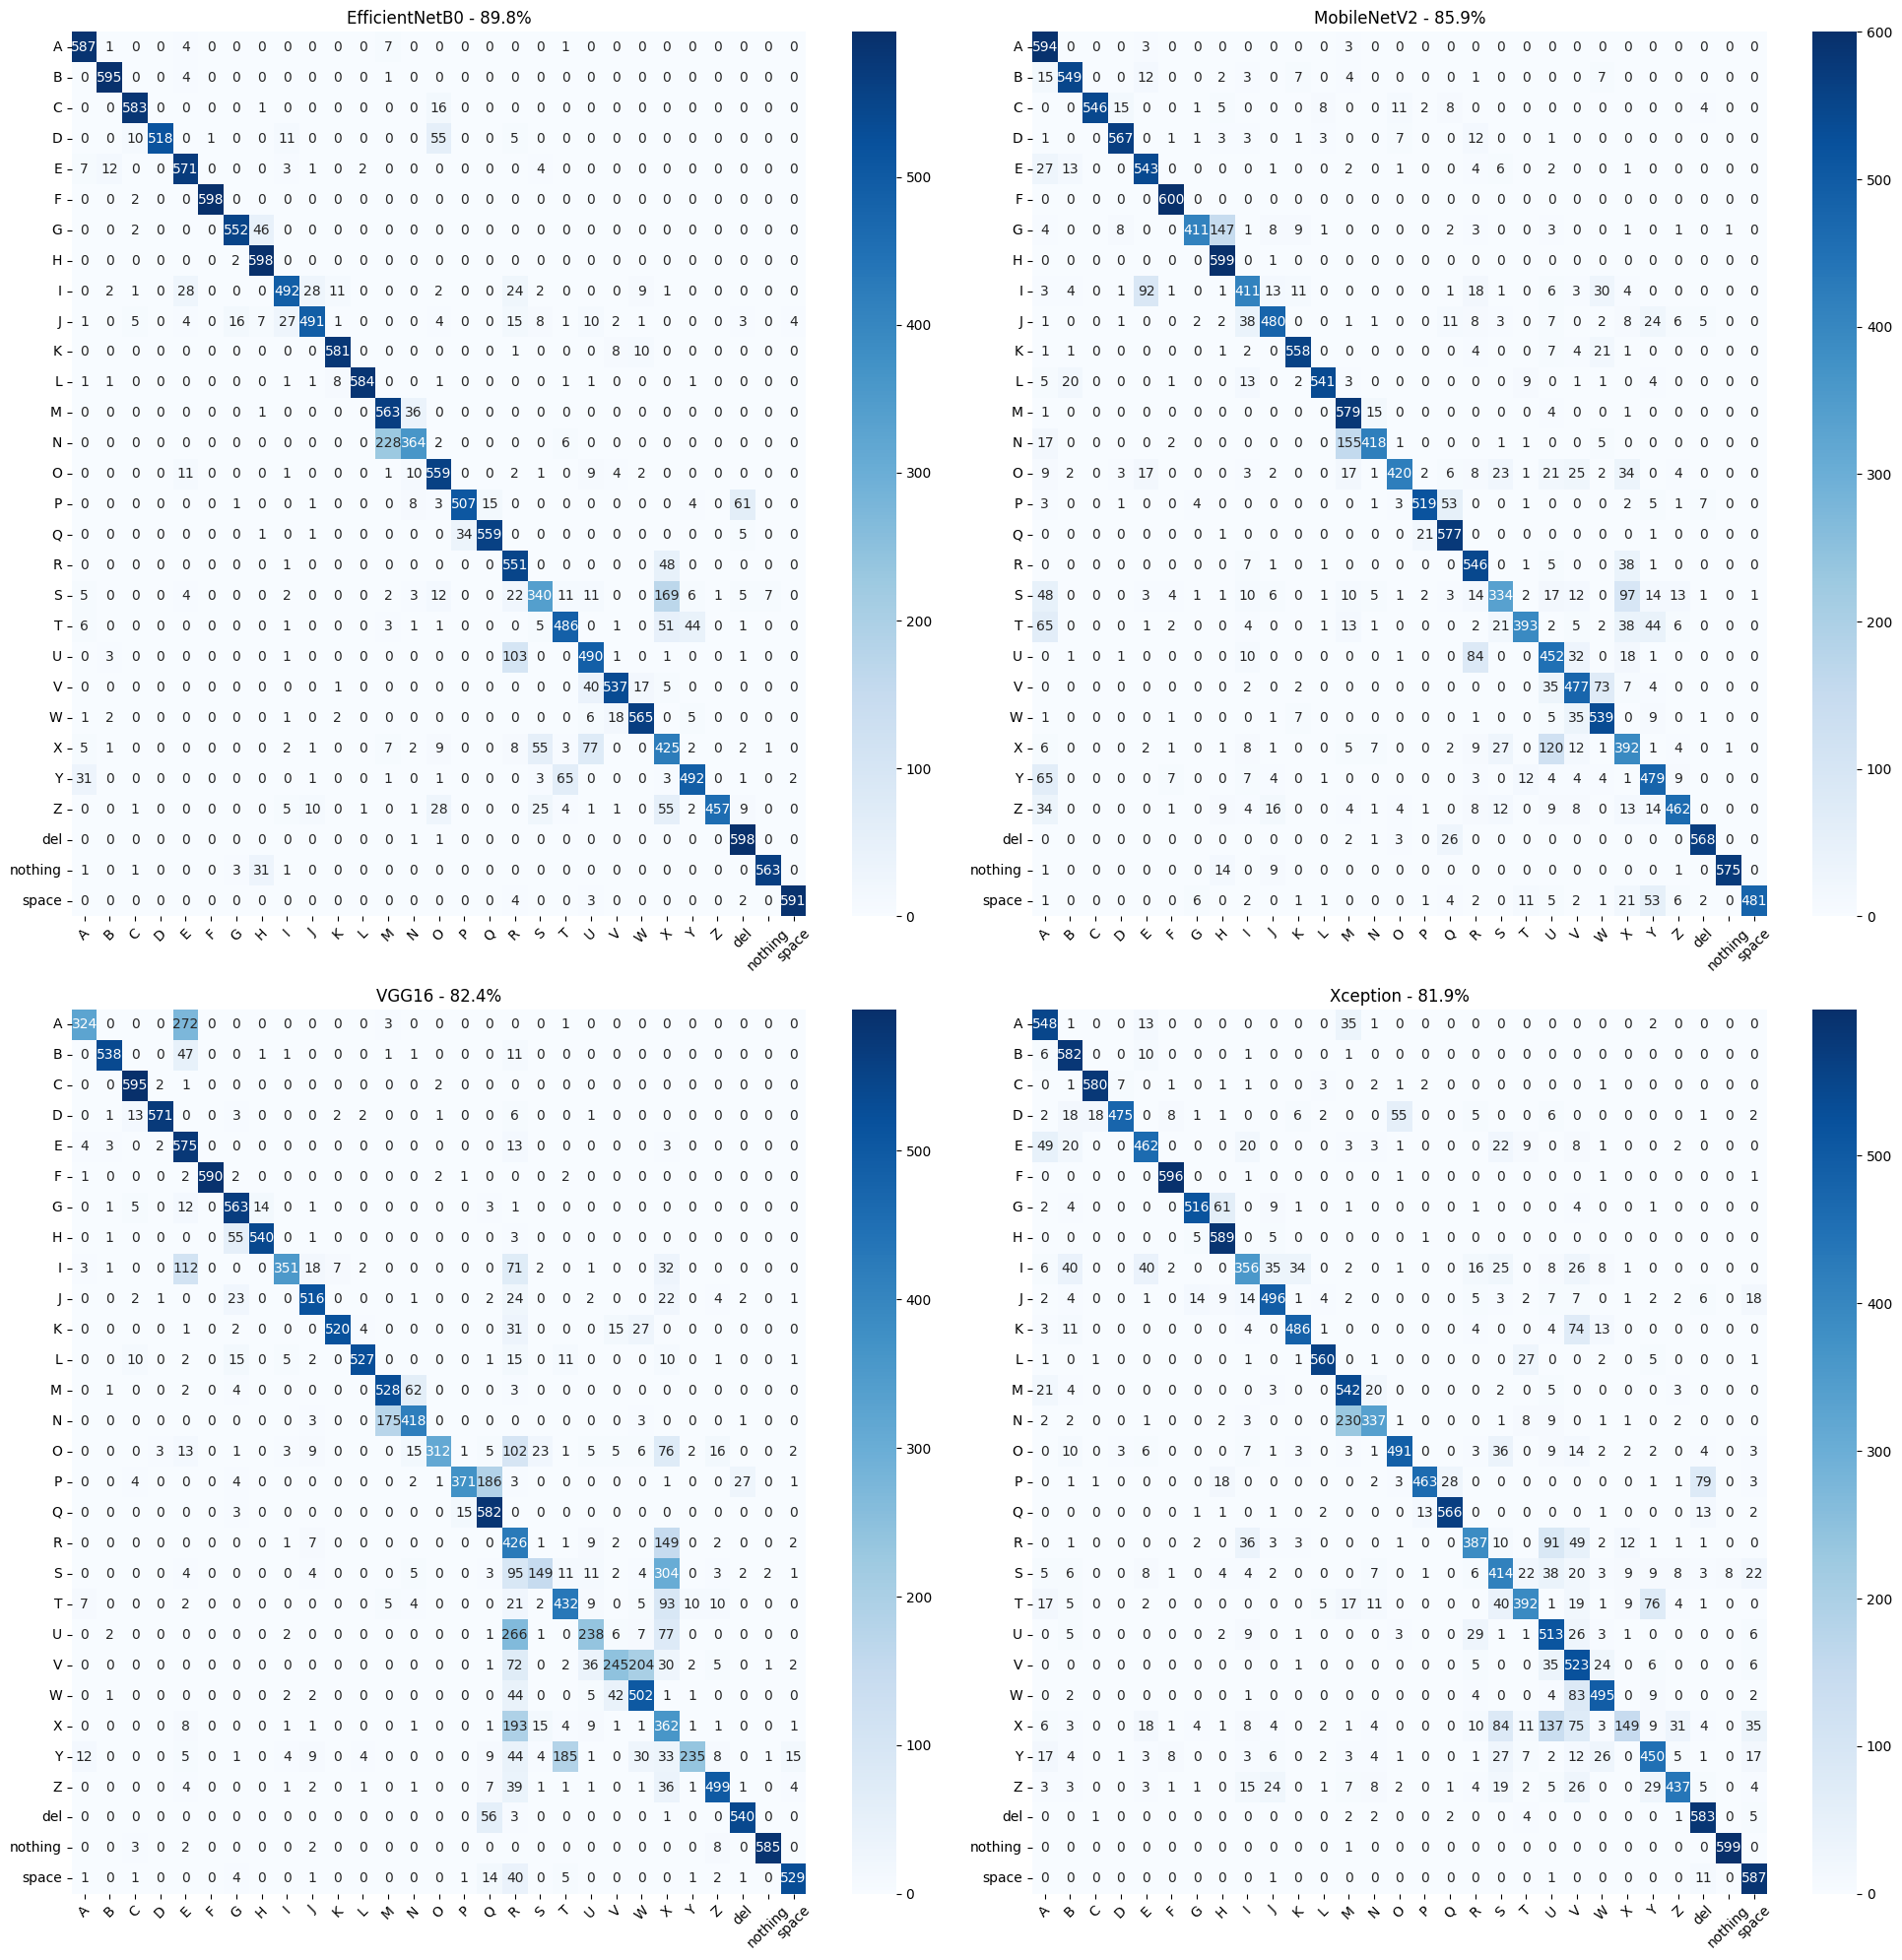

In [9]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes = axes.flatten()

for idx, (key, config) in enumerate(MODEL_CONFIGS.items()):
    clear_memory()
    model = load_model(f'{MODEL_SAVE_DIR}/{key}_final.keras')
    _, val_gen = create_generators(config['preprocess'])
    val_gen.reset()
    
    preds = model.predict(val_gen, verbose=0)
    cm = confusion_matrix(val_gen.classes, np.argmax(preds, axis=1))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels, ax=axes[idx])
    axes[idx].set_title(f"{config['name']} - {results[key]['val_acc']:.1%}")
    axes[idx].tick_params(axis='x', rotation=45)
    del model

plt.tight_layout()
plt.savefig(f'{MODEL_SAVE_DIR}/all_confusion_matrices.png', dpi=150)
plt.show()

## Save Best Model for Flask

In [10]:
import shutil

best_key = max(results, key=lambda k: results[k]['val_acc'])
src = f'{MODEL_SAVE_DIR}/{best_key}_final.keras'
dst = f'{MODEL_SAVE_DIR}/best_asl_model.keras'

shutil.copy(src, dst)
print(f"✅ Best model saved: {dst}")
print(f"   Model: {MODEL_CONFIGS[best_key]['name']}")
print(f"   Accuracy: {results[best_key]['val_acc']:.2%}")

✅ Best model saved: ../models/best_asl_model.keras
   Model: EfficientNetB0
   Accuracy: 89.76%


---
## ✅ Done! Run `python app.py` to start Flask.